# 04 - Model Comparison

## Core-course evaluation subset
To avoid first-year compulsory courses and volatile/optional courses dominating the metric, we evaluate a "core-course" subset by removing:

- `first_year_courses = ['330212', '330213', '330214', '330215', '330216']`
- `optional_courses = ['330054', '330058', '330060', '330063', '330066', '330082', '330097', '330099', '330101', '330102', '330119', '330120', '330244', '330245', '330246', '330247', '330248', '330249', '330094']`

This produces a more meaningful comparison across models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.preprocessing import RobustScaler

from educast.config import (
    NUM_COURSES, FEAT_DIM_STUDENT, MICRO_WINDOW_SIZE, MACRO_WINDOW_SIZE,
    SPLIT_YEAR, RANDOM_SEED, EXCLUDE_FIRST_YEAR_IDS, EXCLUDE_OPTIONAL_IDS,
)
from educast.data.loader import load_university_json, build_course_vocabulary, build_course_label_map
from educast.data.transforms import create_macro_dataset, create_macro_extended_dataset
from educast.data.splits import split_by_year, split_by_term_string
from educast.features.multihot import build_student_dataset, build_macro_windows
from educast.evaluation.metrics import (
    compute_mae, compute_mae_positive, compute_mae_negative,
    per_course_mae, build_comparison_results, summarize_comparison,
)

## 1. Load Data

In [2]:
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)

print(f"Courses: {len(course_ids)}, Students: {len(university_data['students'])}")

Courses: 51, Students: 505


## 2. Prepare All Datasets

Both datasets are built from the same source so all models use identical train/test splits.

In [3]:
# --- Student-level data ---
X_s_all, y_s_all, meta_s_all = build_student_dataset(
    university_data, course_to_idx, MICRO_WINDOW_SIZE
)
X_train_s, y_train_s, meta_train_s, X_test_s, y_test_s, meta_test_s = split_by_year(
    X_s_all, y_s_all, meta_s_all, SPLIT_YEAR
)
print(f"Student-level: train={len(X_train_s)}, test={len(X_test_s)}")

# --- Macro-level data ---
df_macro = create_macro_dataset(university_data, course_ids)
df_extended = create_macro_extended_dataset(university_data, course_ids)
count_cols = [c for c in df_extended.columns if c.startswith("Count_")]

scaler_x = RobustScaler()
scaler_y = RobustScaler()
data_x = scaler_x.fit_transform(df_extended.values)
data_y = scaler_y.fit_transform(df_extended[count_cols].values)
terms = df_extended.index.tolist()

X_m_all, y_m_all, meta_m_all = build_macro_windows(data_x, data_y, terms, MACRO_WINDOW_SIZE)
X_train_m, y_train_m, meta_train_m, X_test_m, y_test_m, meta_test_m = split_by_term_string(
    X_m_all, y_m_all, meta_m_all, SPLIT_YEAR
)
print(f"Macro-level: train={len(X_train_m)}, test={len(X_test_m)}")

Student-level: train=1322, test=836
Macro-level: train=15, test=7


## 3. Train Models

**Naïve model:** no training needed; copies the same-semester enrollment from the previous year (lag=2).
This captures annual seasonality, which is the dominant pattern in the data.
Any model that fails to beat Naïve is adding noise rather than signal.

In [4]:
# --- Naive ---
from educast.models.naive import NaiveModel

naive_model = NaiveModel(lag=2)
naive_model.fit(df_macro)
print("Naive model ready.")

Naive model ready.


In [5]:
# --- Micro LSTM ---
from educast.models.lstm_micro import MicroLSTMTrainer

micro_trainer = MicroLSTMTrainer(
    input_dim=X_train_s.shape[2], hidden_size=64, epochs=100, num_layers=2,
    batch_size=64, seed=RANDOM_SEED,
)
print("Training Micro LSTM...")
micro_trainer.fit(X_train_s, y_train_s)

Training Micro LSTM...


{'train_loss': [0.643243952801353,
  0.3559956723137906,
  0.2702448415128808,
  0.2611650408882844,
  0.25991717765205785,
  0.25939786120464925,
  0.2592008984402606,
  0.25948679917737055,
  0.25887429165212733,
  0.2594690934607857,
  0.2585983739087456,
  0.2587089507203353,
  0.2593590515224557,
  0.25909077964330973,
  0.2594012743548343,
  0.259526631549785,
  0.25863287401826757,
  0.2587574908607884,
  0.259016542058242,
  0.2589960725683915,
  0.2591795137054042,
  0.2584386844384043,
  0.25898843533114385,
  0.2586485594511032,
  0.25772118489993245,
  0.2575719458492179,
  0.2555379114652935,
  0.24962901049538663,
  0.23685125379185928,
  0.21772686823418266,
  0.20312871117340892,
  0.19513521853246188,
  0.18867103833901255,
  0.1837627942624845,
  0.17625319330315842,
  0.1687039576078716,
  0.16146570051971235,
  0.1531263707499755,
  0.1473723406854429,
  0.14211340248584747,
  0.13609479250092255,
  0.1306898237058991,
  0.12327649993331809,
  0.11816216142554033,
 

In [6]:
# --- Macro LSTM ---
from educast.models.lstm_macro import MacroLSTMTrainer

macro_trainer = MacroLSTMTrainer(
    input_dim=X_train_m.shape[2], hidden_size=128, epochs=100,
    batch_size=4, seed=RANDOM_SEED,
)
print("Training Macro LSTM...")
macro_trainer.fit(X_train_m, y_train_m)

Training Macro LSTM...


{'train_loss': [1.069546028971672,
  1.0291998907923698,
  0.9840988293290138,
  0.9193997979164124,
  0.8522549942135811,
  0.8040716797113419,
  0.7671965733170509,
  0.7187565416097641,
  0.6663633808493614,
  0.6482640206813812,
  0.6016840264201164,
  0.5731627941131592,
  0.5406601130962372,
  0.5056996569037437,
  0.4709039591252804,
  0.4302864149212837,
  0.44025737419724464,
  0.397343035787344,
  0.3615810312330723,
  0.3417300432920456,
  0.3330903500318527,
  0.29561005532741547,
  0.27322935312986374,
  0.25178636237978935,
  0.24742190912365913,
  0.22992005199193954,
  0.2287536971271038,
  0.20146581530570984,
  0.19262021780014038,
  0.19997806288301945,
  0.17555239982903004,
  0.17863298207521439,
  0.16570823825895786,
  0.16625875979661942,
  0.15895733051002026,
  0.15976348146796227,
  0.15554512664675713,
  0.14176765084266663,
  0.13824955746531487,
  0.13354851305484772,
  0.1456323117017746,
  0.1386980563402176,
  0.13262551836669445,
  0.14976118505001068,

## 4. Generate Predictions

Predictions for all 3 models are aligned to the same 7 test terms (2018-01 through 2021-01).
- **Naïve:** direct lookup
- **Micro LSTM:** sum sigmoid probabilities over all active students per term
- **Macro LSTM:** inverse-scale LSTM output, clip negatives to 0

In [7]:
# Macro predictions
pred_m_scaled = macro_trainer.predict(X_test_m)
pred_m_real = np.maximum(0, scaler_y.inverse_transform(pred_m_scaled))
actuals_m = scaler_y.inverse_transform(y_test_m)

# Student predictions aggregated to course level
pred_s_probs = micro_trainer.predict(X_test_s)
student_agg = defaultdict(lambda: np.zeros(NUM_COURSES))
for i, (year, term, sid) in enumerate(meta_test_s):
    student_agg[f"{year}-{term:02d}"] += pred_s_probs[i]

# Naive predictions
naive_preds = naive_model.predict(meta_test_m)

print(f"Predictions generated for {len(meta_test_m)} test terms.")

Predictions generated for 7 test terms.


## 5. Compare Results

**Exclusions from evaluation:**
- `EXCLUDE_FIRST_YEAR_IDS`: 5 first-year compulsory courses (trivially predicted; dominated by cohort size)
- `EXCLUDE_OPTIONAL_IDS`: 19 optional courses (too sparse and irregular)

In [ ]:
results = []
for i, term_str in enumerate(meta_test_m):
    actuals_row = actuals_m[i]
    p_macro = pred_m_real[i]
    p_student = student_agg.get(term_str, np.zeros(NUM_COURSES))
    p_naive = naive_preds[i]
    
    for c_idx in range(NUM_COURSES):
        if actuals_row[c_idx] == 0 and p_macro[c_idx] == 0 and p_student[c_idx] == 0:
            continue
        results.append({
            "Term": term_str,
            "Course": idx_to_course.get(c_idx, f"ID_{c_idx}"),
            "Actual": actuals_row[c_idx],
            "Pred_Naive": p_naive[c_idx],
            "Pred_Student": p_student[c_idx],
            "Pred_Macro": max(0, p_macro[c_idx]),
        })

df_results = pd.DataFrame(results)
for model in ["Naive", "Student", "Macro"]:
    df_results[f"Err_{model}"] = (df_results["Actual"] - df_results[f"Pred_{model}"]).abs()

# Global MAE (excluding first-year + optional courses)
exclude_ids = set(EXCLUDE_FIRST_YEAR_IDS + EXCLUDE_OPTIONAL_IDS)
df_clean = df_results[~df_results["Course"].isin(exclude_ids)]

mae_scores = {
    "Naive": df_clean["Err_Naive"].mean(),
    "Student": df_clean["Err_Student"].mean(),
    "Macro": df_clean["Err_Macro"].mean(),
}
for name, mae in mae_scores.items():
    print(f"{name:10s} MAE: {mae:.2f}")

Naive      MAE: 2.07
Student    MAE: 2.06
Macro      MAE: 5.73


The Micro LSTM improvement (~0.2 students/course) is modest and likely not statistically significant
over only 7 test terms. The Macro LSTM's failure confirms the overfitting seen previously.

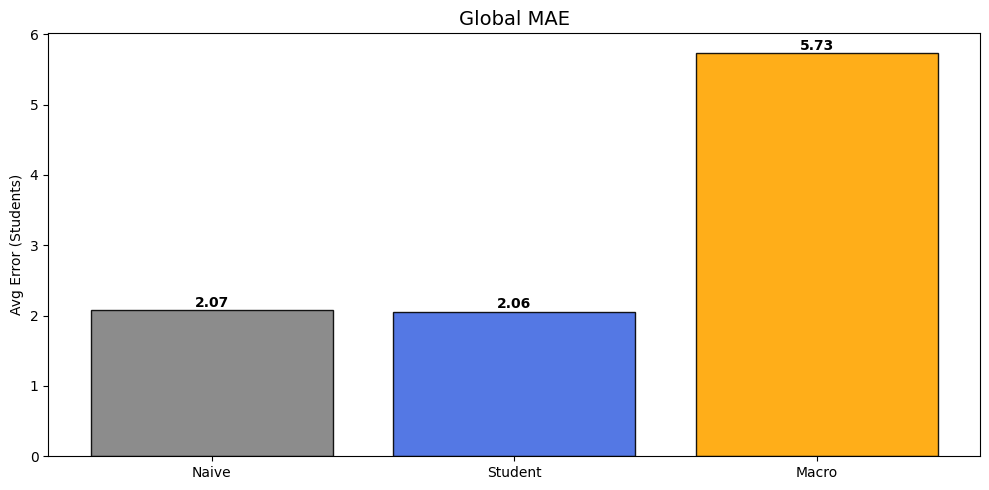

In [ ]:
from educast.visualization.plots import plot_global_mae_comparison
fig = plot_global_mae_comparison(mae_scores)
plt.show()

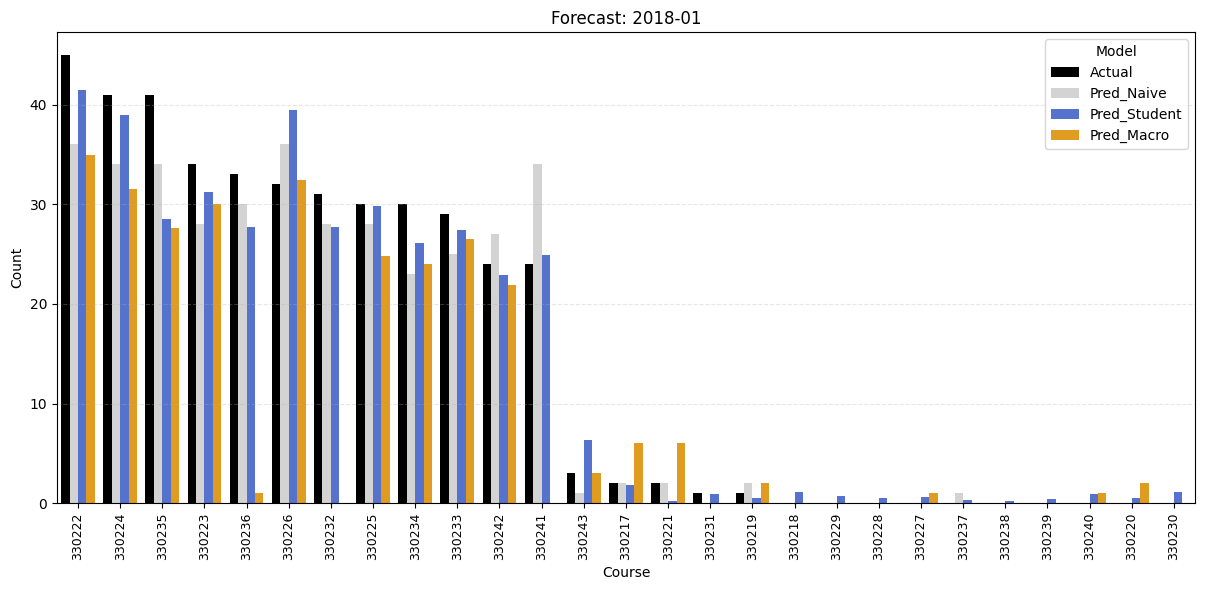

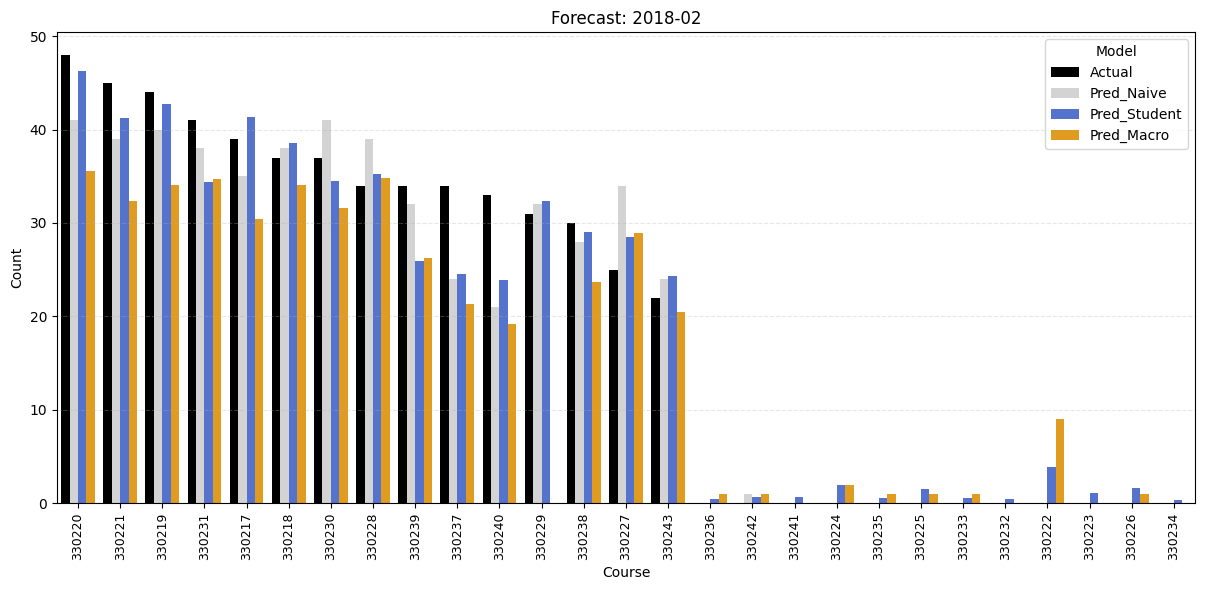

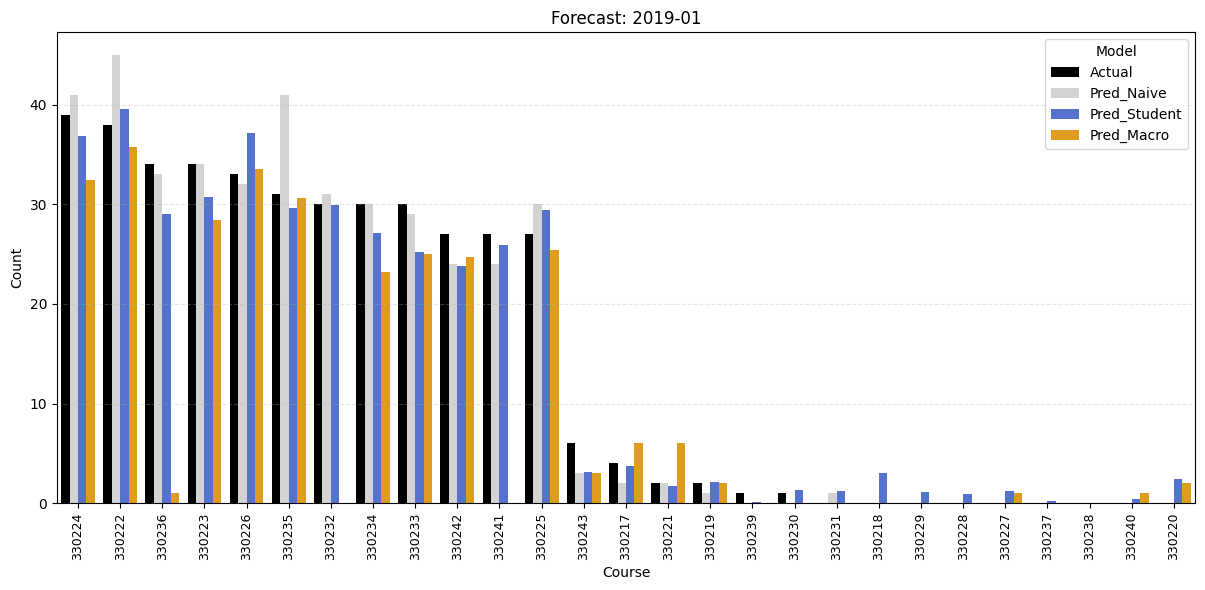

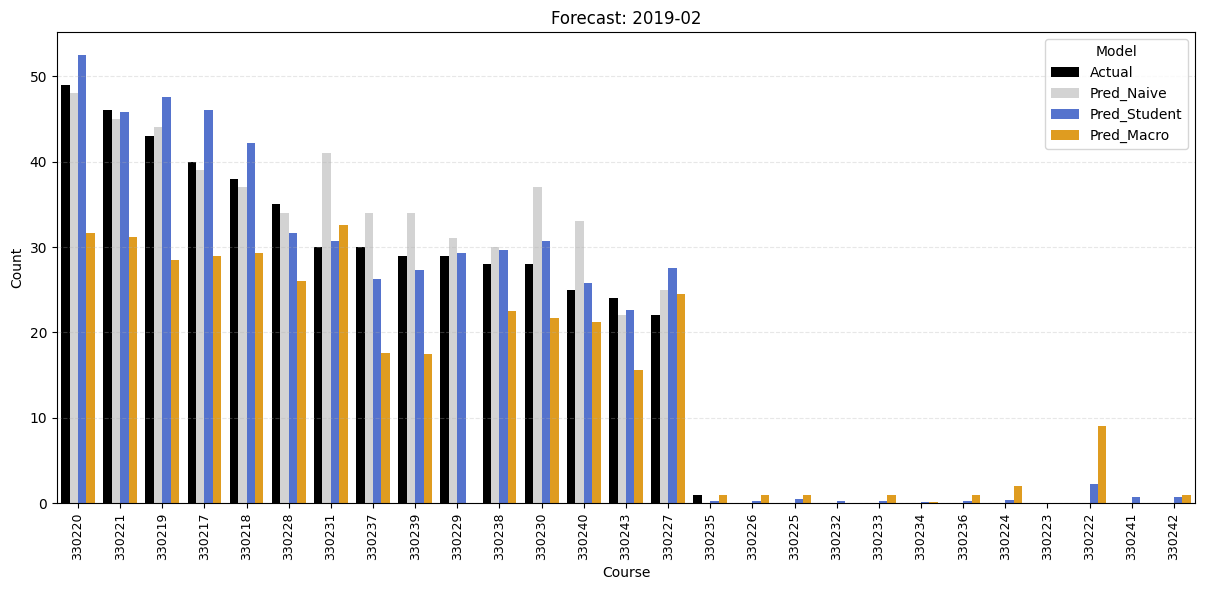

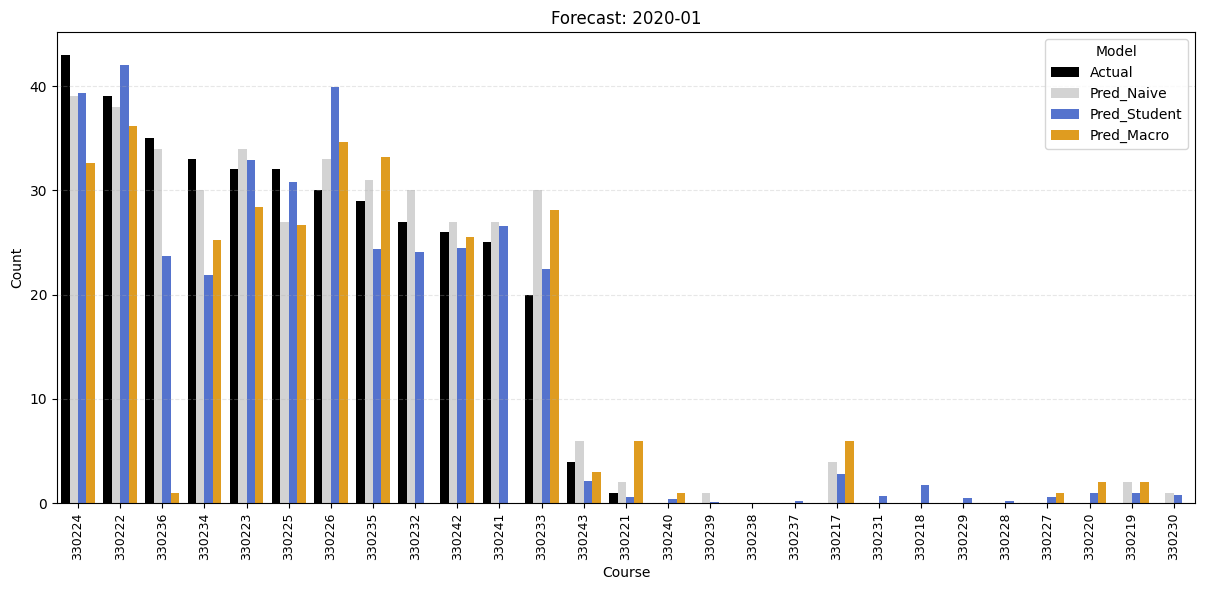

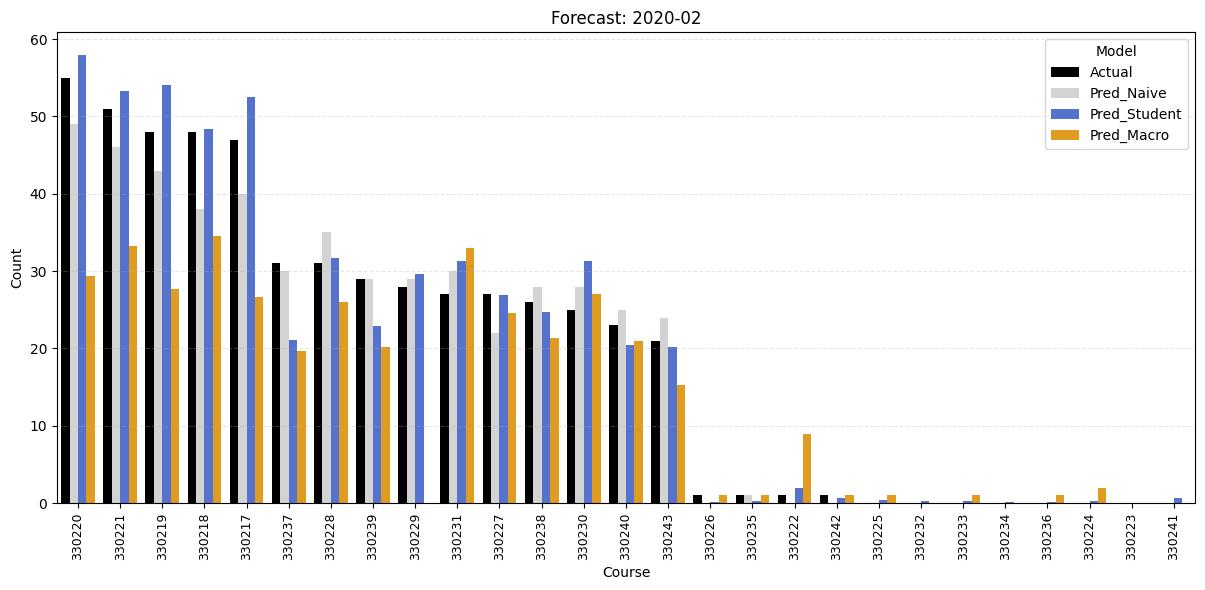

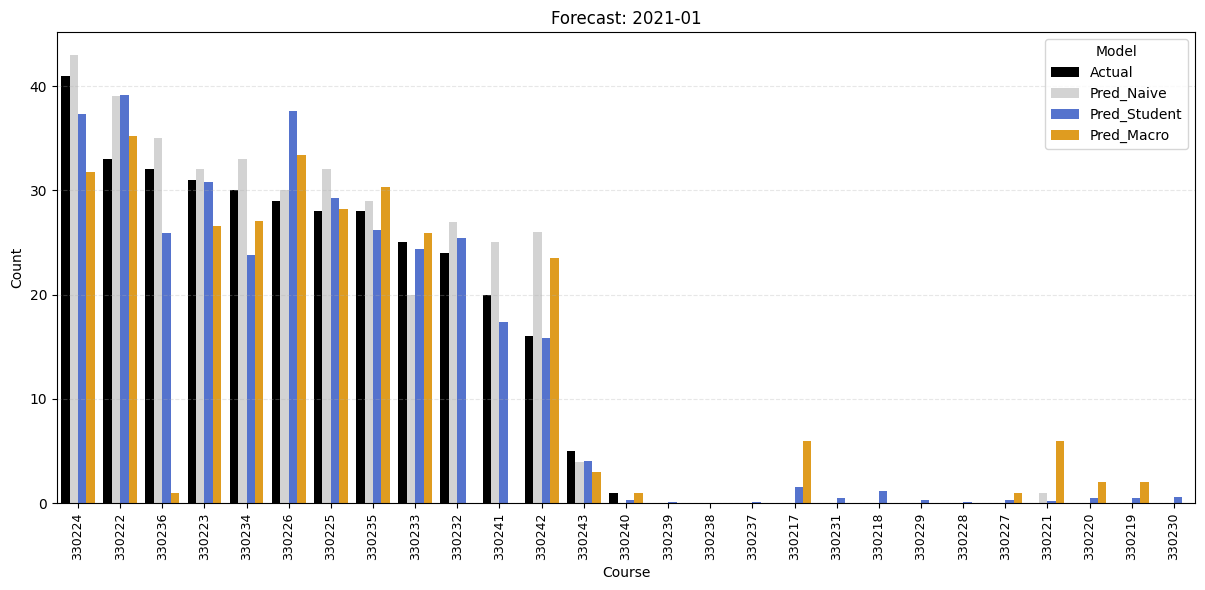

In [ ]:
for term in sorted(df_clean["Term"].unique()):
    df_term = df_clean[df_clean["Term"] == term].sort_values("Actual", ascending=False).head(30)
    if df_term.empty:
        continue
    
    df_melt = df_term.melt(
        id_vars=["Course"],
        value_vars=["Actual", "Pred_Naive", "Pred_Student", "Pred_Macro"],
        var_name="Model", value_name="Count",
    )
    plt.figure(figsize=(max(12, len(df_term) * 0.45), 6))
    sns.barplot(data=df_melt, x="Course", y="Count", hue="Model",
                palette={"Actual": "black", "Pred_Naive": "lightgray",
                         "Pred_Student": "royalblue", "Pred_Macro": "orange"})
    plt.title(f"Forecast: {term}")
    plt.xticks(rotation=90, fontsize=9)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

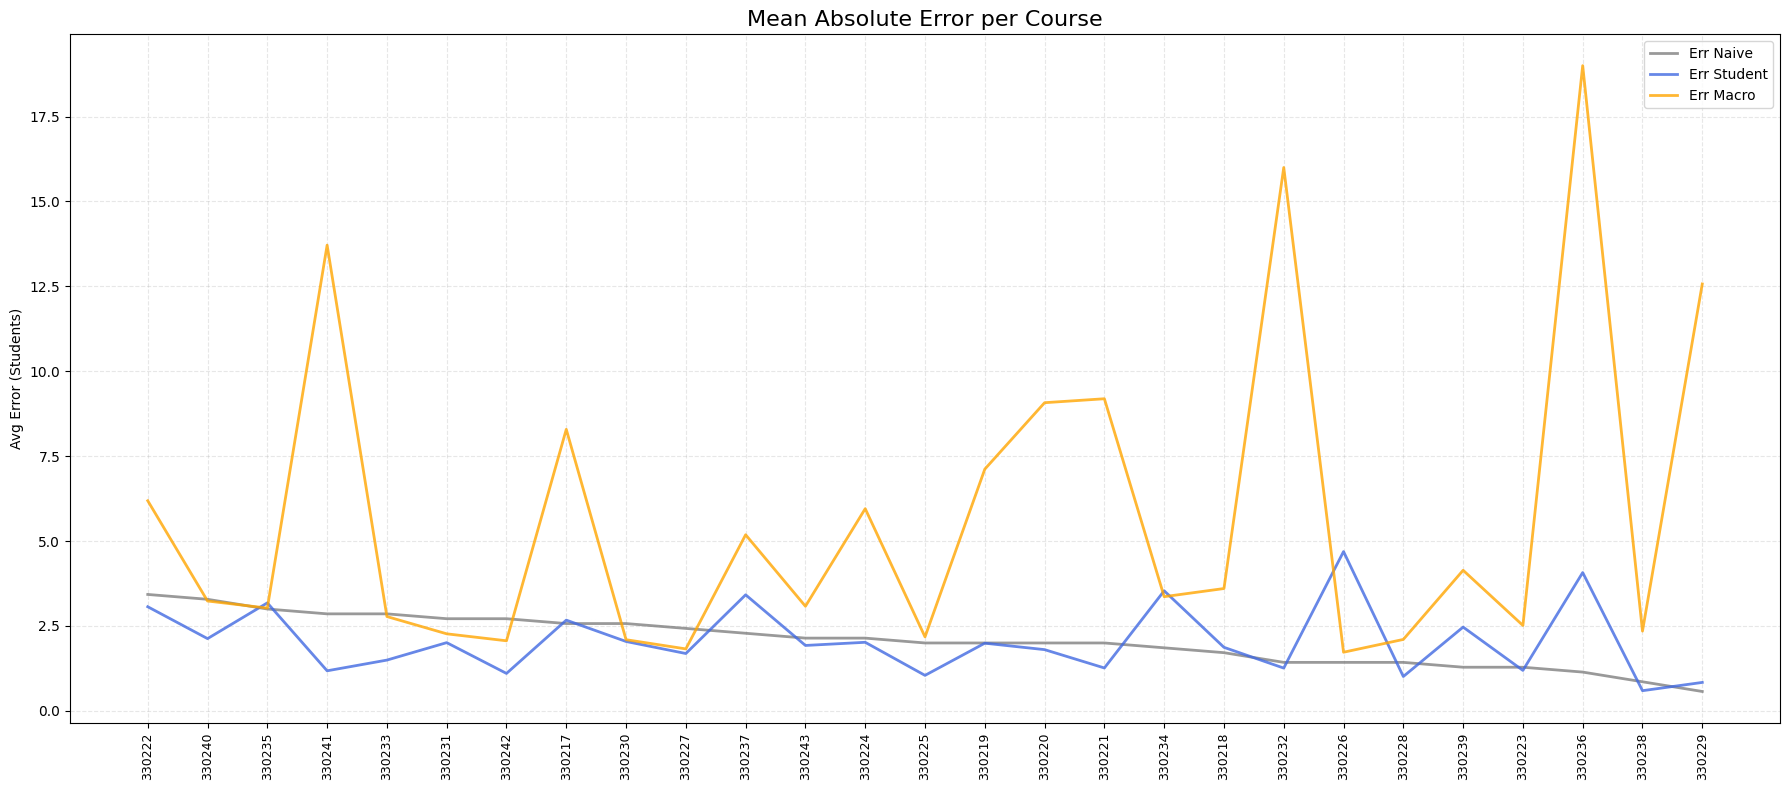

In [11]:
# Per-course MAE comparison
from educast.visualization.plots import plot_per_course_mae
fig = plot_per_course_mae(df_clean, ["Naive", "Student", "Macro"])
plt.show()

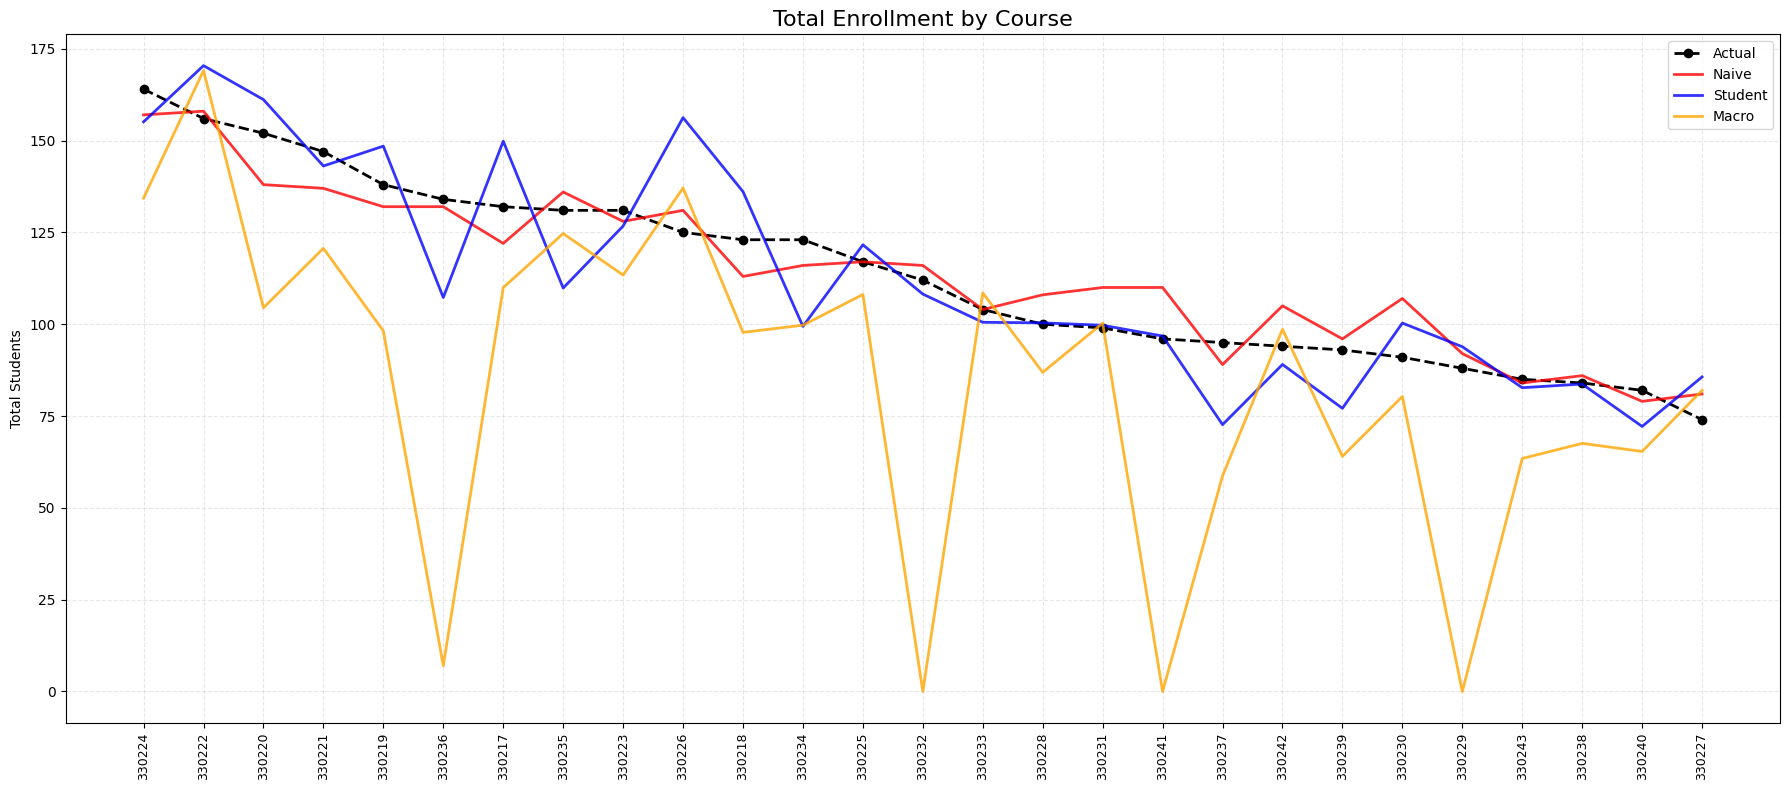

In [ ]:
from educast.visualization.plots import plot_enrollment_total_comparison
fig = plot_enrollment_total_comparison(df_clean, ["Naive", "Student", "Macro"])
plt.show()

- Seasonal naïve (1-year lag) is a strong baseline for semester data.
- Excluding first-year compulsory + optional courses produces a more meaningful *core-course* benchmark.
- Micro (student-level) models can match the naïve baseline, but gains are small at this data scale.

In [13]:
from educast.evaluation.export import export_results

metrics = {f"MAE_{k}": v for k, v in mae_scores.items()}
df_export = df_clean.groupby("Course").agg({
    "Err_Naive": "mean", "Err_Student": "mean", "Err_Macro": "mean",
}).reset_index()
df_export.columns = ["Course", "MAE_Naive", "MAE_Student", "MAE_Macro"]

json_path, csv_path = export_results(
    "comparison_all", metrics, df_export,
    {"models": ["Naive", "Student", "Macro"], "split_year": SPLIT_YEAR,
     "excluded_courses": len(exclude_ids)}
)
print(f"Saved: {json_path}\n        {csv_path}")

Saved: /Users/anassanhari/EPSEM/TFM/educast/results/comparison_all_20260510_080548.json
        /Users/anassanhari/EPSEM/TFM/educast/results/comparison_all_20260510_080548_per_course.csv
